# Scheme Success Model

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
import joblib

df = pd.read_csv("../../data/raw/historical_scheme_data.csv")
df["EMI_to_Price_Ratio"] = df["Monthly_EMI_INR"] / df["Price_INR"]
df["AdBudget_per_Sqft"] = df["Advertising_Budget_INR"] / df["Plot_Size_SqFt"]
df.head()


,Scheme_ID,Location,Plot_Size_SqFt,Price_INR,Monthly_EMI_INR,Park,Clubhouse,Distance_from_Metro_km,Advertising_Budget_INR,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Demand_Level,Scheme_Success_Score,Target_Age_Group,Most_Likely_Buyers,EMI_to_Price_Ratio,AdBudget_per_Sqft
0,SCH_0101,Delhi (Outer/Bawana),800,1320000,9200,Yes,No,3.9,1500000,3230,602,18.6,HIGH,79,25-38,First-time Buyers & Investors,0.006970,1875.000000
1,SCH_0102,Gurugram (SPR/Sohna),1800,8270000,57400,Yes,Yes,16.2,1500000,2335,348,14.9,HIGH,79,40-60,Affluent Investors & Luxury Homes,0.006941,833.333333
2,SCH_0103,Kolkata (New Town/Rajarhat),1500,3030000,21000,Yes,No,5.5,750000,1267,227,17.9,MEDIUM,74,25-38,First-time Buyers & Investors,0.006931,500.000000
3,SCH_0104,Bengaluru (North),1000,6360000,44200,Yes,No,23.9,1000000,1015,99,9.8,LOW,41,32-48,Self-use (Villa) + Investment,0.006950,1000.000000
4,SCH_0105,Greater Noida,2400,8150000,56600,No,No,23.4,1000000,1180,73,6.2,LOW,25,40-60,Affluent Investors & Luxury Homes,0.006945,416.666667


## Part 1 - Regression

In [2]:
input_features = ["Location", "Plot_Size_SqFt", "Price_INR", "Monthly_EMI_INR",
                   "Park", "Clubhouse", "Distance_from_Metro_km", "Advertising_Budget_INR",
                   "EMI_to_Price_Ratio", "AdBudget_per_Sqft"]
target_cols = ["Expected_Leads", "Expected_Bookings", "Estimated_Conversion_Pct", "Scheme_Success_Score"]

X = pd.get_dummies(df[input_features], columns=["Location", "Park", "Clubhouse"], drop_first=True)
y = df[target_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [3]:
def evaluate_multi(model, name):
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    r2 = r2_score(y_test, pred, multioutput="uniform_average")
    per = r2_score(y_test, pred, multioutput="raw_values")
    print(f"{name}: avg R2={r2:.3f}")
    return model, r2, per

lr_model, lr_r2, lr_per = evaluate_multi(LinearRegression(), "Linear Regression")

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), {"n_estimators":[100,200], "max_depth":[10,15]}, cv=3, scoring="r2")
rf_grid.fit(X_train_s, y_train)
rf_model, rf_r2, rf_per = evaluate_multi(rf_grid.best_estimator_, "Tuned Random Forest")

gb_grid = GridSearchCV(MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
                        {"estimator__n_estimators":[100,200], "estimator__learning_rate":[0.05,0.1], "estimator__max_depth":[2,3]},
                        cv=3, scoring="r2")
gb_grid.fit(X_train_s, y_train)
gb_model, gb_r2, gb_per = evaluate_multi(gb_grid.best_estimator_, "Tuned Gradient Boosting")

reg_results = pd.DataFrame({t: [lr_per[i], rf_per[i], gb_per[i]] for i, t in enumerate(target_cols)},
                            index=["Linear Regression", "Tuned Random Forest", "Tuned Gradient Boosting"])
reg_results["Avg_R2"] = [lr_r2, rf_r2, gb_r2]
reg_results


Linear Regression: avg R2=0.669
Tuned Random Forest: avg R2=0.641
Tuned Gradient Boosting: avg R2=0.733


,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Scheme_Success_Score,Avg_R2
Linear Regression,0.884427,0.732708,0.365076,0.693312,0.668881
Tuned Random Forest,0.921192,0.798654,0.250337,0.594454,0.641160
Tuned Gradient Boosting,0.926721,0.847313,0.408259,0.751451,0.733436


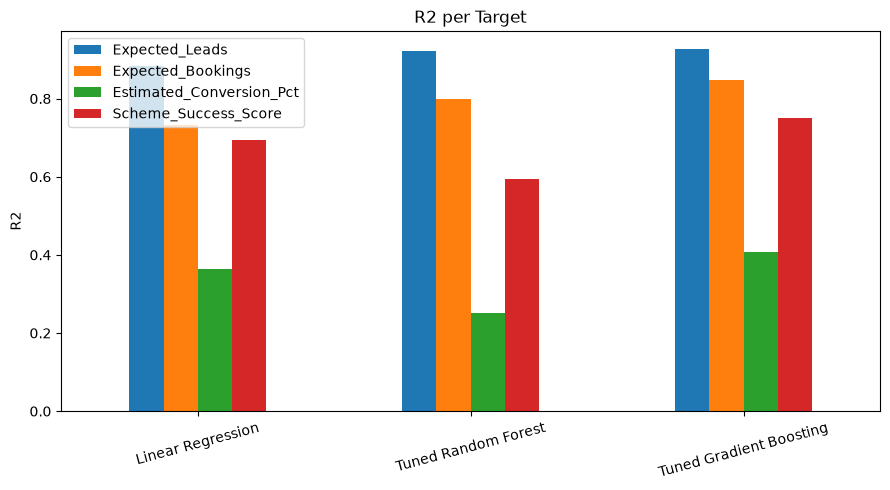

In [4]:
reg_results[target_cols].plot(kind="bar", figsize=(9,5))
plt.title("R2 per Target"); plt.ylabel("R2"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()


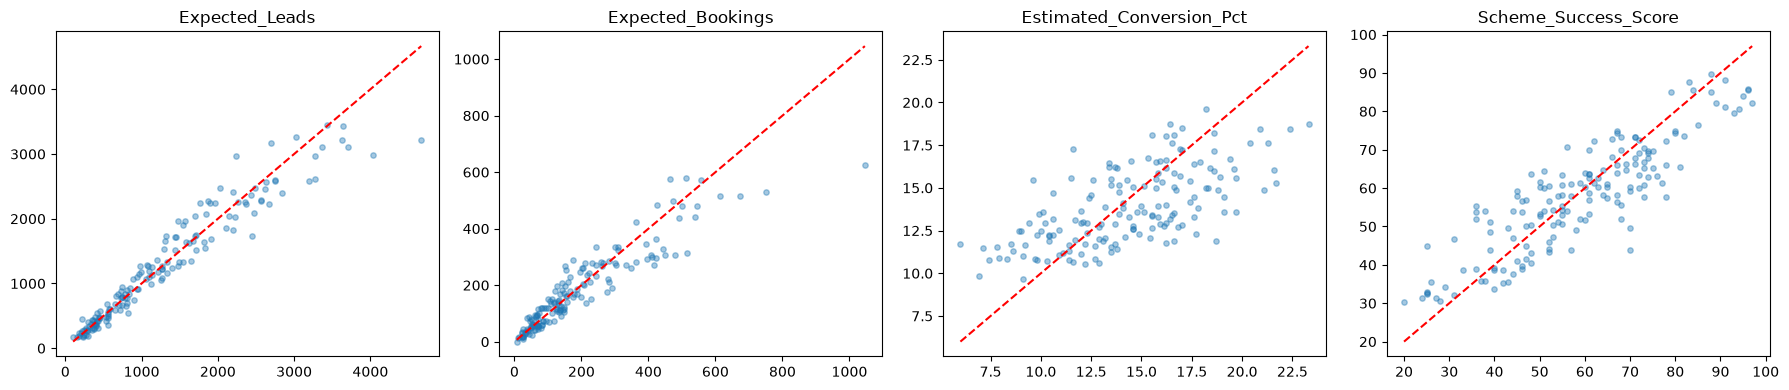

In [5]:
best_reg_name = reg_results["Avg_R2"].idxmax()
best_reg_model = {"Linear Regression": lr_model, "Tuned Random Forest": rf_model, "Tuned Gradient Boosting": gb_model}[best_reg_name]

pred = best_reg_model.predict(X_test_s)
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col, i in zip(axes, target_cols, range(4)):
    ax.scatter(y_test[col], pred[:, i], alpha=0.4, s=15)
    lims = [y_test[col].min(), y_test[col].max()]
    ax.plot(lims, lims, "r--"); ax.set_title(col)
plt.tight_layout(); plt.show()


In [6]:
joblib.dump(best_reg_model, "../../models/scheme_multi_output_model.pkl")
joblib.dump(scaler, "../../models/scheme_reg_scaler.pkl")
joblib.dump(list(X.columns), "../../models/scheme_reg_columns.pkl")
joblib.dump(target_cols, "../../models/scheme_reg_targets.pkl")
print("Saved:", best_reg_name)


Saved: Tuned Gradient Boosting


## Part 2 - Classification

In [7]:
Xc = pd.get_dummies(df[input_features], columns=["Location", "Park", "Clubhouse"], drop_first=True)
yc = df["Demand_Level"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
clf_scaler = MinMaxScaler()
Xc_train_s = clf_scaler.fit_transform(Xc_train)
Xc_test_s = clf_scaler.transform(Xc_test)

def evaluate_clf(model, name):
    model.fit(Xc_train_s, yc_train)
    pred = model.predict(Xc_test_s)
    acc = accuracy_score(yc_test, pred)
    print(f"{name}: accuracy={acc:.3f}")
    return model, acc

lr_clf, lr_acc = evaluate_clf(LogisticRegression(max_iter=1000, class_weight="balanced"), "Logistic Regression")
gb_clf, gb_acc = evaluate_clf(GradientBoostingClassifier(n_estimators=200, random_state=42), "Gradient Boosting")

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                        {"n_estimators":[100,200], "max_depth":[8,15]}, cv=3, scoring="f1_macro")
rf_grid.fit(Xc_train_s, yc_train)
rf_clf, rf_acc = evaluate_clf(rf_grid.best_estimator_, "Tuned Random Forest")

clf_results = pd.DataFrame({"Model": ["Logistic Regression","Gradient Boosting","Tuned Random Forest"],
                             "Accuracy": [lr_acc, gb_acc, rf_acc]}).set_index("Model")
clf_results


Logistic Regression: accuracy=0.662
Gradient Boosting: accuracy=0.756
Tuned Random Forest: accuracy=0.769


,Accuracy
Model,
Logistic Regression,0.66250
Gradient Boosting,0.75625
Tuned Random Forest,0.76875


              precision    recall  f1-score   support

        HIGH       0.75      0.84      0.79        25
         LOW       0.74      0.80      0.77        56
      MEDIUM       0.80      0.72      0.76        79

    accuracy                           0.77       160
   macro avg       0.76      0.79      0.77       160
weighted avg       0.77      0.77      0.77       160



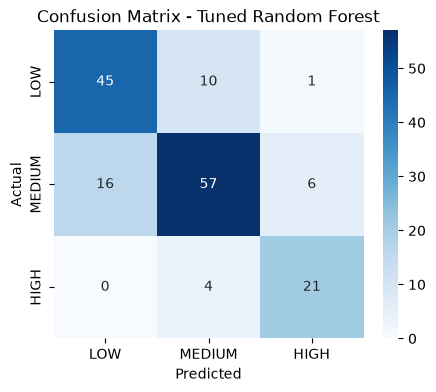

In [8]:
best_clf_name = clf_results["Accuracy"].idxmax()
best_clf_model = {"Logistic Regression": lr_clf, "Gradient Boosting": gb_clf, "Tuned Random Forest": rf_clf}[best_clf_name]
print(classification_report(yc_test, best_clf_model.predict(Xc_test_s)))

cm = confusion_matrix(yc_test, best_clf_model.predict(Xc_test_s), labels=["LOW","MEDIUM","HIGH"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["LOW","MEDIUM","HIGH"], yticklabels=["LOW","MEDIUM","HIGH"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix - {best_clf_name}")
plt.show()


In [9]:
joblib.dump(best_clf_model, "../../models/scheme_demand_classifier.pkl")
joblib.dump(clf_scaler, "../../models/scheme_demand_scaler.pkl")
joblib.dump(list(Xc.columns), "../../models/scheme_demand_columns.pkl")
print("Saved:", best_clf_name)


Saved: Tuned Random Forest
